In [1]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
from matplotlib import pyplot as plt

In [2]:
device = torch.device('mps' if torch.mps.is_available else 'cpu')
device

device(type='mps')

## Load Data

In [3]:
image_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

In [4]:
dataset_path = "./dataset"

dataset = datasets.ImageFolder(root = dataset_path, transform=image_transform)
len(dataset)

2300

In [5]:
dataset.classes

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [6]:
class_names = dataset.classes

In [7]:
num_classes = len(dataset.classes)
num_classes

6

In [8]:
train_size = int(len(dataset)*0.75)
val_size = len(dataset) - train_size

In [9]:
train_size, val_size

(1725, 575)

In [10]:
from torch.utils.data import random_split

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [11]:
train_loader = DataLoader(train_dataset, batch_size= 32, shuffle= True)
val_loader = DataLoader(val_dataset, batch_size= 32, shuffle= True)

In [12]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [13]:
labels[0]

tensor(2)

In [14]:
images[0].shape

torch.Size([3, 224, 224])

In [15]:
images[0].permute(1,2,0).shape

torch.Size([224, 224, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.535425].


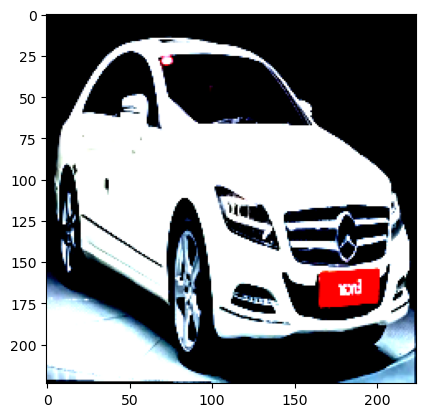

In [16]:
plt.imshow(images[0].permute(1,2,0))
plt.show()

## Model 1: CNN

In [17]:
class CarClassificaitonCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels= 3, out_channels=16, kernel_size=3, stride=1, padding=1),#(16,224,224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0 ),#(16,112,112)
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1,padding=1), #(32,112,112)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2,padding=0), #(32,56,56)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3,stride=1, padding=1),#(64,56,56)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0 ), #(64,28,28)
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Linear(512,num_classes)
        )

    def forward(self,x):
        x = self.network(x)

        return x

In [18]:
#Initiating the model , loss function and optimizer

model = CarClassificaitonCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr= 0.001)

In [19]:
def train_model(model, criterion, optimizer, epochs=5):
    start = time.time()

    for epoch in range(int(epochs)):
        model.train()
        running_loss = 0.0
        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            # forward pass
            outputs = model(images)
            loss = criterion(outputs,labels)

            # backward pass and optimization
            loss.backward()
            optimizer.step()

            if (batch_num+1)%10 == 0 :
                print(f"Batch : {batch_num+1}, Epoch:{ epoch+1}, Loss: {loss.item():0.2f}")

            running_loss +=loss.item() *images.size(0)

        epoch_loss = running_loss/len(train_loader.dataset)
        print(f"Epoch [{epoch+1}/{epochs}], Avg Loss: {epoch_loss:.4f}")



        # validation 
        model.eval()
        correct = 0
        total = 0
        all_labels = []
        all_predictions = []

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                _ , predicted = torch.max(outputs.data, 1)
                total +=labels.size(0)
                correct += (predicted == labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predicted.cpu().numpy())

            print(f" *** validation Accuracy: {100* correct/ total:.2f}% ***")
    end = time.time()
    print(f" Execution Time: {end- start}seconds")
    return all_labels, all_predictions


    




In [20]:
train_model(model, criterion, optimizer,epochs=5)

Batch : 10, Epoch:1, Loss: 1.79
Batch : 20, Epoch:1, Loss: 1.88
Batch : 30, Epoch:1, Loss: 1.79
Batch : 40, Epoch:1, Loss: 1.79
Batch : 50, Epoch:1, Loss: 1.80
Epoch [1/5], Avg Loss: 1.9007
 *** validation Accuracy: 18.78% ***
Batch : 10, Epoch:2, Loss: 1.80
Batch : 20, Epoch:2, Loss: 1.76
Batch : 30, Epoch:2, Loss: 1.80
Batch : 40, Epoch:2, Loss: 1.71
Batch : 50, Epoch:2, Loss: 1.80
Epoch [2/5], Avg Loss: 1.7771
 *** validation Accuracy: 22.09% ***
Batch : 10, Epoch:3, Loss: 1.82
Batch : 20, Epoch:3, Loss: 1.66
Batch : 30, Epoch:3, Loss: 1.83
Batch : 40, Epoch:3, Loss: 1.85
Batch : 50, Epoch:3, Loss: 1.77
Epoch [3/5], Avg Loss: 1.7746
 *** validation Accuracy: 21.22% ***
Batch : 10, Epoch:4, Loss: 1.86
Batch : 20, Epoch:4, Loss: 1.78
Batch : 30, Epoch:4, Loss: 1.74
Batch : 40, Epoch:4, Loss: 1.75
Batch : 50, Epoch:4, Loss: 1.79
Epoch [4/5], Avg Loss: 1.7710
 *** validation Accuracy: 21.22% ***
Batch : 10, Epoch:5, Loss: 1.82
Batch : 20, Epoch:5, Loss: 1.77
Batch : 30, Epoch:5, Loss: 1

([1,
  3,
  3,
  2,
  2,
  1,
  5,
  1,
  5,
  3,
  1,
  2,
  0,
  5,
  5,
  2,
  2,
  0,
  2,
  2,
  0,
  3,
  4,
  5,
  2,
  1,
  5,
  0,
  1,
  0,
  3,
  5,
  0,
  3,
  1,
  2,
  0,
  4,
  0,
  4,
  1,
  2,
  3,
  3,
  3,
  0,
  4,
  2,
  4,
  2,
  5,
  0,
  3,
  4,
  2,
  1,
  2,
  5,
  4,
  0,
  2,
  3,
  5,
  1,
  2,
  2,
  5,
  4,
  3,
  0,
  2,
  5,
  5,
  4,
  3,
  1,
  0,
  4,
  0,
  1,
  1,
  0,
  4,
  1,
  5,
  2,
  0,
  1,
  1,
  0,
  5,
  4,
  2,
  1,
  2,
  0,
  1,
  5,
  0,
  1,
  2,
  1,
  2,
  3,
  0,
  3,
  1,
  0,
  0,
  2,
  2,
  1,
  5,
  3,
  5,
  3,
  1,
  0,
  0,
  3,
  3,
  2,
  2,
  2,
  3,
  2,
  4,
  5,
  1,
  0,
  0,
  3,
  4,
  2,
  3,
  2,
  3,
  3,
  2,
  0,
  5,
  1,
  4,
  4,
  1,
  0,
  4,
  1,
  1,
  0,
  4,
  4,
  2,
  0,
  4,
  4,
  2,
  0,
  3,
  2,
  5,
  2,
  0,
  2,
  4,
  1,
  0,
  1,
  2,
  5,
  2,
  0,
  1,
  0,
  0,
  2,
  4,
  4,
  2,
  0,
  0,
  0,
  5,
  1,
  0,
  2,
  1,
  4,
  1,
  0,
  2,
  4,
  3,
  2,
  2,
  0,
  1,
  2,
  3,
  3,


## Model 2: CNN with Regularization

In [21]:
class CarClassificaitonCNNWithRegularization(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels= 3, out_channels=16, kernel_size=3, stride=1, padding=1),#(16,224,224)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0 ),#(16,112,112)
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1,padding=1), #(32,112,112)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2,padding=0), #(32,56,56)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3,stride=1, padding=1),#(64,56,56)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0 ), #(64,28,28)
            nn.Flatten(),
            nn.Linear(64*28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512,num_classes)
        )

    def forward(self,x):
        x = self.network(x)

        return x

In [22]:
model = CarClassificaitonCNNWithRegularization(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr= 0.001, weight_decay=1e-4) # L2 Regularization

In [23]:
train_model(model, criterion , optimizer, epochs=10)

Batch : 10, Epoch:1, Loss: 45.62
Batch : 20, Epoch:1, Loss: 50.06
Batch : 30, Epoch:1, Loss: 54.17
Batch : 40, Epoch:1, Loss: 31.92
Batch : 50, Epoch:1, Loss: 13.10
Epoch [1/10], Avg Loss: 37.1493
 *** validation Accuracy: 11.30% ***
Batch : 10, Epoch:2, Loss: 3.28
Batch : 20, Epoch:2, Loss: 3.21
Batch : 30, Epoch:2, Loss: 1.90
Batch : 40, Epoch:2, Loss: 1.80
Batch : 50, Epoch:2, Loss: 1.77
Epoch [2/10], Avg Loss: 3.4256
 *** validation Accuracy: 14.78% ***
Batch : 10, Epoch:3, Loss: 1.69
Batch : 20, Epoch:3, Loss: 1.78
Batch : 30, Epoch:3, Loss: 2.10
Batch : 40, Epoch:3, Loss: 1.78
Batch : 50, Epoch:3, Loss: 1.72
Epoch [3/10], Avg Loss: 1.7907
 *** validation Accuracy: 21.39% ***
Batch : 10, Epoch:4, Loss: 1.79
Batch : 20, Epoch:4, Loss: 1.78
Batch : 30, Epoch:4, Loss: 1.79
Batch : 40, Epoch:4, Loss: 1.75
Batch : 50, Epoch:4, Loss: 1.76
Epoch [4/10], Avg Loss: 1.8276
 *** validation Accuracy: 22.09% ***
Batch : 10, Epoch:5, Loss: 1.80
Batch : 20, Epoch:5, Loss: 1.75
Batch : 30, Epoch:

([0,
  4,
  2,
  1,
  0,
  0,
  4,
  5,
  1,
  1,
  5,
  0,
  0,
  2,
  2,
  1,
  2,
  4,
  1,
  0,
  1,
  0,
  2,
  3,
  0,
  0,
  1,
  3,
  0,
  1,
  5,
  1,
  5,
  2,
  5,
  4,
  4,
  1,
  0,
  5,
  2,
  0,
  4,
  4,
  0,
  0,
  1,
  5,
  4,
  5,
  4,
  2,
  3,
  2,
  4,
  2,
  0,
  0,
  1,
  4,
  0,
  2,
  2,
  3,
  1,
  2,
  0,
  3,
  2,
  2,
  1,
  2,
  2,
  0,
  4,
  1,
  2,
  2,
  1,
  0,
  4,
  3,
  5,
  0,
  2,
  3,
  2,
  4,
  2,
  5,
  2,
  1,
  4,
  2,
  2,
  2,
  1,
  2,
  3,
  5,
  5,
  3,
  0,
  0,
  0,
  0,
  2,
  4,
  0,
  0,
  4,
  0,
  5,
  2,
  1,
  5,
  0,
  3,
  0,
  1,
  3,
  2,
  0,
  0,
  0,
  4,
  4,
  1,
  5,
  4,
  3,
  5,
  0,
  2,
  3,
  3,
  3,
  1,
  3,
  3,
  4,
  2,
  0,
  3,
  4,
  5,
  4,
  0,
  0,
  5,
  0,
  3,
  1,
  2,
  5,
  0,
  2,
  2,
  0,
  1,
  2,
  1,
  2,
  3,
  1,
  2,
  5,
  2,
  2,
  2,
  2,
  2,
  0,
  5,
  1,
  0,
  2,
  2,
  3,
  2,
  4,
  1,
  1,
  3,
  5,
  0,
  3,
  0,
  1,
  1,
  3,
  0,
  4,
  4,
  3,
  1,
  0,
  2,
  1,
  0,


## Model 4: Transfer Learning using EfficientNet

In [24]:
import torchvision.models as models



In [25]:
class CarClassifierEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(weights='DEFAULT')

        for param in self.model.parameters():
            param.requires_grad = False


        in_features = self.model.classifier[1].in_features

        self.model.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )
    
    def forward(self,x):
        x = self.model(x)

        return x


In [26]:
model = CarClassifierEfficientNet(num_classes).to(device)

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

train_model(model,criterion, optimizer, epochs=10)

Batch : 10, Epoch:1, Loss: 1.62
Batch : 20, Epoch:1, Loss: 1.71
Batch : 30, Epoch:1, Loss: 1.43
Batch : 40, Epoch:1, Loss: 1.61
Batch : 50, Epoch:1, Loss: 1.16
Epoch [1/10], Avg Loss: 1.4543
 *** validation Accuracy: 52.00% ***
Batch : 10, Epoch:2, Loss: 1.48
Batch : 20, Epoch:2, Loss: 1.53
Batch : 30, Epoch:2, Loss: 1.56
Batch : 40, Epoch:2, Loss: 3.17
Batch : 50, Epoch:2, Loss: 3.64
Epoch [2/10], Avg Loss: 1.7653
 *** validation Accuracy: 52.35% ***
Batch : 10, Epoch:3, Loss: 2.41
Batch : 20, Epoch:3, Loss: 2.04
Batch : 30, Epoch:3, Loss: 2.52
Batch : 40, Epoch:3, Loss: 3.95
Batch : 50, Epoch:3, Loss: 2.91
Epoch [3/10], Avg Loss: 2.7779
 *** validation Accuracy: 62.78% ***
Batch : 10, Epoch:4, Loss: 2.70
Batch : 20, Epoch:4, Loss: 4.57
Batch : 30, Epoch:4, Loss: 5.44
Batch : 40, Epoch:4, Loss: 6.39
Batch : 50, Epoch:4, Loss: 4.34
Epoch [4/10], Avg Loss: 4.0603
 *** validation Accuracy: 44.00% ***
Batch : 10, Epoch:5, Loss: 5.02
Batch : 20, Epoch:5, Loss: 8.15
Batch : 30, Epoch:5, Los

([4,
  1,
  0,
  1,
  2,
  5,
  0,
  0,
  2,
  4,
  1,
  1,
  5,
  0,
  3,
  1,
  5,
  3,
  0,
  2,
  5,
  4,
  5,
  0,
  4,
  1,
  0,
  5,
  3,
  3,
  5,
  3,
  3,
  0,
  4,
  1,
  0,
  0,
  2,
  4,
  5,
  5,
  0,
  4,
  4,
  0,
  2,
  3,
  3,
  0,
  2,
  0,
  0,
  4,
  0,
  3,
  5,
  5,
  2,
  2,
  5,
  5,
  5,
  4,
  0,
  0,
  2,
  0,
  3,
  0,
  3,
  1,
  0,
  0,
  4,
  5,
  0,
  1,
  3,
  0,
  3,
  5,
  3,
  0,
  2,
  2,
  5,
  1,
  0,
  4,
  1,
  0,
  5,
  1,
  0,
  2,
  1,
  1,
  3,
  2,
  0,
  3,
  0,
  0,
  1,
  5,
  4,
  1,
  1,
  4,
  2,
  0,
  5,
  3,
  2,
  4,
  1,
  5,
  3,
  5,
  4,
  4,
  0,
  3,
  3,
  1,
  4,
  2,
  1,
  0,
  3,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  1,
  4,
  2,
  0,
  4,
  2,
  1,
  1,
  3,
  2,
  0,
  2,
  2,
  1,
  0,
  5,
  3,
  3,
  0,
  0,
  1,
  1,
  4,
  2,
  4,
  0,
  0,
  2,
  4,
  1,
  0,
  5,
  0,
  2,
  5,
  1,
  5,
  1,
  2,
  2,
  1,
  4,
  3,
  1,
  2,
  0,
  1,
  4,
  2,
  0,
  2,
  1,
  5,
  2,
  5,
  3,
  5,
  2,
  0,
  5,
  5,
  4,


## Model 5 : Transfer Learning using the ResNet

In [27]:
class CarClassificaitonResNet(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')
        
        # freezing all layers except the final fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False
        
        # unfreezing layer4 and fc layers
        for param in self.model.layer4.parameters():
            param.requires_grad = True

        # replacing the final fully connected layer
        
        self.model.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.model.fc.in_features, num_classes)
        )

    def forward(self,x):
        x = self.model(x)

        return x

        

In [28]:
model = CarClassificaitonResNet(num_classes).to(device)

optimizer = optim.Adam(filter(lambda p : p.requires_grad, model.parameters()), lr=0.001)

In [29]:
labels, predictions = train_model(model,criterion, optimizer, epochs=10)

Batch : 10, Epoch:1, Loss: 1.23
Batch : 20, Epoch:1, Loss: 0.78
Batch : 30, Epoch:1, Loss: 0.99
Batch : 40, Epoch:1, Loss: 1.07
Batch : 50, Epoch:1, Loss: 0.77
Epoch [1/10], Avg Loss: 1.1253
 *** validation Accuracy: 29.04% ***
Batch : 10, Epoch:2, Loss: 1.24
Batch : 20, Epoch:2, Loss: 0.74
Batch : 30, Epoch:2, Loss: 0.62
Batch : 40, Epoch:2, Loss: 1.07
Batch : 50, Epoch:2, Loss: 0.96
Epoch [2/10], Avg Loss: 0.9548
 *** validation Accuracy: 67.65% ***
Batch : 10, Epoch:3, Loss: 1.07
Batch : 20, Epoch:3, Loss: 1.22
Batch : 30, Epoch:3, Loss: 0.50
Batch : 40, Epoch:3, Loss: 0.66
Batch : 50, Epoch:3, Loss: 0.83
Epoch [3/10], Avg Loss: 0.8656
 *** validation Accuracy: 58.26% ***
Batch : 10, Epoch:4, Loss: 0.78
Batch : 20, Epoch:4, Loss: 0.75
Batch : 30, Epoch:4, Loss: 0.32
Batch : 40, Epoch:4, Loss: 0.48
Batch : 50, Epoch:4, Loss: 0.85
Epoch [4/10], Avg Loss: 0.7613
 *** validation Accuracy: 67.83% ***
Batch : 10, Epoch:5, Loss: 0.90
Batch : 20, Epoch:5, Loss: 1.40
Batch : 30, Epoch:5, Los

After Performing the Hyperparameter Tuning the best parameters which we found are learning_rate: 0.00029998576473226775 and dropout_rate: 0.6593149255258369 

In [30]:
best_lr = 0.00029998576473226775
best_drop_rate = 0.6593149255258369

In [31]:
class CarClassificaitonResNet(nn.Module):
    def __init__(self,num_classes, drop_rate):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')
        
        # freezing all layers except the final fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False
        
        # unfreezing layer4 and fc layers
        for param in self.model.layer4.parameters():
            param.requires_grad = True

        # replacing the final fully connected layer
        
        self.model.fc = nn.Sequential(
            nn.Dropout(drop_rate),
            nn.Linear(self.model.fc.in_features, num_classes)
        )

    def forward(self,x):
        x = self.model(x)

        return x

In [32]:
model_with_best_params = CarClassificaitonResNet(num_classes=num_classes, drop_rate=best_drop_rate).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(filter(lambda p : p.requires_grad, model_with_best_params.parameters()), lr = best_lr)


In [33]:
labels, predictions = train_model(model_with_best_params, criterion, optimizer, epochs=10)

Batch : 10, Epoch:1, Loss: 1.55
Batch : 20, Epoch:1, Loss: 1.29
Batch : 30, Epoch:1, Loss: 0.70
Batch : 40, Epoch:1, Loss: 0.84
Batch : 50, Epoch:1, Loss: 1.04
Epoch [1/10], Avg Loss: 1.1331
 *** validation Accuracy: 61.04% ***
Batch : 10, Epoch:2, Loss: 0.84
Batch : 20, Epoch:2, Loss: 0.87
Batch : 30, Epoch:2, Loss: 0.50
Batch : 40, Epoch:2, Loss: 0.61
Batch : 50, Epoch:2, Loss: 0.58
Epoch [2/10], Avg Loss: 0.7087
 *** validation Accuracy: 63.65% ***
Batch : 10, Epoch:3, Loss: 0.56
Batch : 20, Epoch:3, Loss: 0.57
Batch : 30, Epoch:3, Loss: 0.69
Batch : 40, Epoch:3, Loss: 0.64
Batch : 50, Epoch:3, Loss: 0.94
Epoch [3/10], Avg Loss: 0.7457
 *** validation Accuracy: 70.96% ***
Batch : 10, Epoch:4, Loss: 0.47
Batch : 20, Epoch:4, Loss: 0.67
Batch : 30, Epoch:4, Loss: 0.52
Batch : 40, Epoch:4, Loss: 1.25
Batch : 50, Epoch:4, Loss: 0.63
Epoch [4/10], Avg Loss: 0.7879
 *** validation Accuracy: 72.00% ***
Batch : 10, Epoch:5, Loss: 0.54
Batch : 20, Epoch:5, Loss: 0.50
Batch : 30, Epoch:5, Los

In [34]:
from sklearn.metrics import classification_report


## Classification Report

In [35]:
report = classification_report(labels , predictions)
print(report)

              precision    recall  f1-score   support

           0       0.93      0.70      0.80       127
           1       0.62      0.88      0.73       108
           2       0.91      0.84      0.87       122
           3       0.84      0.65      0.74        75
           4       0.67      0.55      0.61        78
           5       0.69      0.98      0.81        65

    accuracy                           0.77       575
   macro avg       0.78      0.77      0.76       575
weighted avg       0.79      0.77      0.77       575



## Confusion Matrix

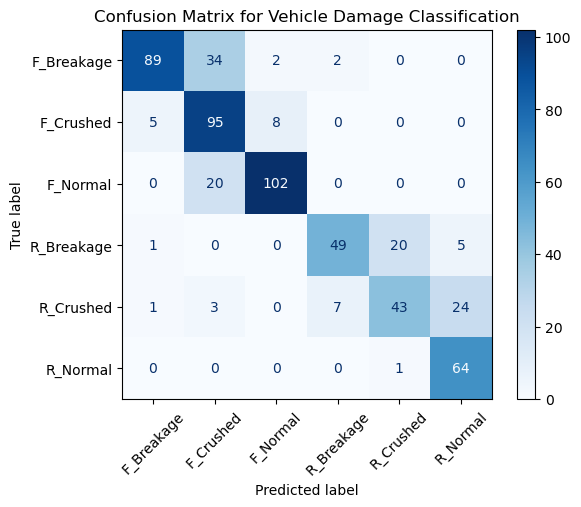

In [36]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

conf_matrix = confusion_matrix(labels, predictions, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Vehicle Damage Classification")
plt.show()

## Save the model

In [37]:
torch.save(model_with_best_params.state_dict(), 'saved_model_Car_Damage_Detection.pth')